# Online Retail Data Analysis

## Objective
Analyze customer behaviour, revenue performance, product performance,
and sales trends to identify important business insights and
provide actionable recommendations.

## Dataset
This project uses the Online Retail dataset containing transaction-level
sales information such as InvoiceNo, StockCode, Description, Quantity,
InvoiceDate, UnitPrice, CustomerID and Country.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\DELL\Downloads\archive (1).zip",
    encoding="latin1"
)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 541909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
## Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
## 2. Missing values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
## . Duplicate rows

print("Duplicate rows:", df.duplicated().sum())



Duplicate rows: 5268


In [6]:
## Numerical summary

df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
## Date range

print("First date:", df["InvoiceDate"].min())
print("Last date:", df["InvoiceDate"].max())

First date: 1/10/2011 10:04
Last date: 9/9/2011 9:52


In [8]:
## Unique customers and countries

print("Unique customers:", df["CustomerID"].nunique())
print("Unique countries:", df["Country"].nunique())

Unique customers: 4372
Unique countries: 38


In [9]:
## negative quantities
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Zero quantities:", (df["Quantity"] == 0).sum())

Negative quantities: 10624
Zero quantities: 0


In [10]:
## negative prices?
print("Negative UnitPrice:", (df["UnitPrice"] < 0).sum())
print("Zero UnitPrice:", (df["UnitPrice"] == 0).sum())

Negative UnitPrice: 2
Zero UnitPrice: 2515


In [11]:
## cancelled invoices
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]
print("Cancelled transactions:", len(cancelled))
cancelled.head(10)

Cancelled transactions: 9288


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom


In [12]:
## suspicious negative-price records
df[df["UnitPrice"] < 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


In [13]:
zero_price = df[df["UnitPrice"] == 0]

print("Zero-price transactions:", len(zero_price))
zero_price.head(20)

Zero-price transactions: 2515


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,12/1/2010 14:35,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,12/1/2010 14:35,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom


In [14]:
print("Zero-price descriptions:")
print(zero_price["Description"].value_counts().head(20))

Zero-price descriptions:
Description
check                              159
?                                   47
damages                             45
damaged                             43
found                               25
sold as set on dotcom               20
adjustment                          16
Damaged                             14
Unsaleable, destroyed.               9
thrown away                          9
FRENCH BLUE METAL DOOR SIGN 1        9
amazon                               8
FRENCH BLUE METAL DOOR SIGN 8        8
Found                                8
FRENCH BLUE METAL DOOR SIGN 4        7
RECIPE BOX PANTRY YELLOW DESIGN      7
Amazon                               7
FRENCH BLUE METAL DOOR SIGN No       7
??                                   7
OWL DOORSTOP                         7
Name: count, dtype: int64


In [15]:
print("Zero-price countries:")
print(zero_price["Country"].value_counts().head(10))

Zero-price countries:
Country
United Kingdom    2497
EIRE                 4
Netherlands          4
Australia            3
Germany              2
Switzerland          1
Spain                1
RSA                  1
France               1
Norway               1
Name: count, dtype: int64


In [16]:
zero_price["Quantity"].describe()

count     2515.000000
mean       -53.421074
std        540.206783
min      -9600.000000
25%        -32.000000
50%         -1.000000
75%          3.000000
max      12540.000000
Name: Quantity, dtype: float64

In [17]:
## duplicates

duplicates = df[df.duplicated(keep=False)]

print("Duplicate rows:", len(duplicates))
duplicates.head(20)

Duplicate rows: 10147


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


In [18]:
duplicates[["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID"]].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0


In [19]:
sales_df = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(sales_df))
print("Duplicates removed:", len(df) - len(sales_df))

Original rows: 541909
Rows after removing duplicates: 536641
Duplicates removed: 5268


In [20]:
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

print(sales_df["InvoiceDate"].dtype)

datetime64[ns]


In [21]:
sales_df = sales_df[
    (~sales_df["InvoiceNo"].astype(str).str.startswith("C")) &
    (sales_df["Quantity"] > 0)
].copy()

print("Rows after removing cancellations/negative quantities:", len(sales_df))

Rows after removing cancellations/negative quantities: 526054


In [22]:
sales_df = sales_df[sales_df["UnitPrice"] > 0].copy()

print("Rows after removing zero/negative prices:", len(sales_df))

Rows after removing zero/negative prices: 524878


In [23]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [24]:
print("Rows:", sales_df.shape[0])
print("Columns:", sales_df.shape[1])

sales_df.info()

Rows: 524878
Columns: 9
<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  object        
 8   Revenue      524878 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 40.0+ MB


In [25]:
print("Missing values:")
print(sales_df.isnull().sum())

Missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64


In [26]:
print("Negative quantities:", (sales_df["Quantity"] < 0).sum())
print("Zero prices:", (sales_df["UnitPrice"] == 0).sum())
print("Negative prices:", (sales_df["UnitPrice"] < 0).sum())
print("Negative revenue:", (sales_df["Revenue"] < 0).sum())

Negative quantities: 0
Zero prices: 0
Negative prices: 0
Negative revenue: 0


In [27]:
sales_df["Year"] = sales_df["InvoiceDate"].dt.year
sales_df["Month"] = sales_df["InvoiceDate"].dt.month
sales_df["Month_Name"] = sales_df["InvoiceDate"].dt.month_name()
sales_df["Year_Month"] = sales_df["InvoiceDate"].dt.to_period("M")

sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Year_Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,2010-12


In [28]:
print("Years:", sales_df["Year"].unique())
print("Months:", sales_df["Month"].unique())

Years: [2010 2011]
Months: [12  1  2  3  4  5  6  7  8  9 10 11]


In [29]:
sales_df["Year_Month"].unique()

<PeriodArray>
['2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06',
 '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12']
Length: 13, dtype: period[M]

In [30]:
## monthly revenue
monthly_revenue = (
    sales_df.groupby("Year_Month")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,Year_Month,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


In [31]:
## monthly orders
monthly_orders = (
    sales_df.groupby("Year_Month")["InvoiceNo"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders

,Year_Month,Orders
0,2010-12,1559
1,2011-01,1086
2,2011-02,1100
3,2011-03,1454
4,2011-04,1246
5,2011-05,1681
6,2011-06,1533
7,2011-07,1475
8,2011-08,1361
9,2011-09,1837


In [32]:
## monthly customers
monthly_customers = (
    sales_df.dropna(subset=["CustomerID"])
    .groupby("Year_Month")["CustomerID"]
    .nunique()
    .reset_index(name="Customers")
)

monthly_customers

,Year_Month,Customers
0,2010-12,885
1,2011-01,741
2,2011-02,758
3,2011-03,974
4,2011-04,856
5,2011-05,1056
6,2011-06,991
7,2011-07,949
8,2011-08,935
9,2011-09,1266


In [33]:
monthly_performance = monthly_revenue.merge(
    monthly_orders,
    on="Year_Month"
).merge(
    monthly_customers,
    on="Year_Month"
)

monthly_performance

,Year_Month,Revenue,Orders,Customers
0,2010-12,821452.730,1559,885
1,2011-01,689811.610,1086,741
2,2011-02,522545.560,1100,758
3,2011-03,716215.260,1454,974
4,2011-04,536968.491,1246,856
5,2011-05,769296.610,1681,1056
6,2011-06,760547.010,1533,991
7,2011-07,718076.121,1475,949
8,2011-08,757841.380,1361,935
9,2011-09,1056435.192,1837,1266


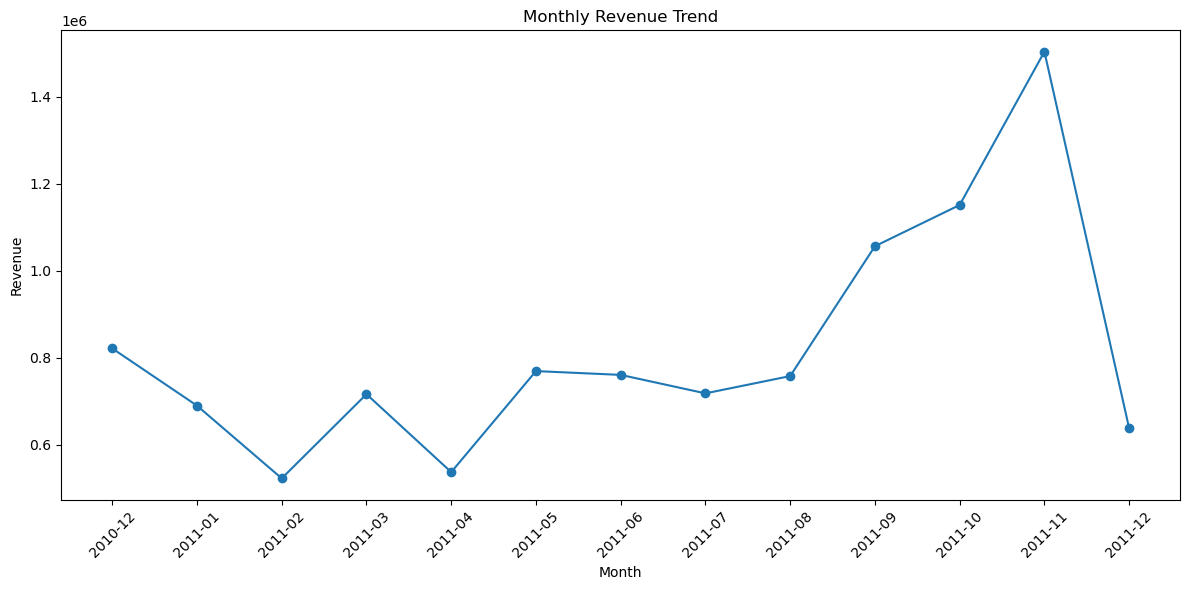

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["Year_Month"].astype(str),
    monthly_performance["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

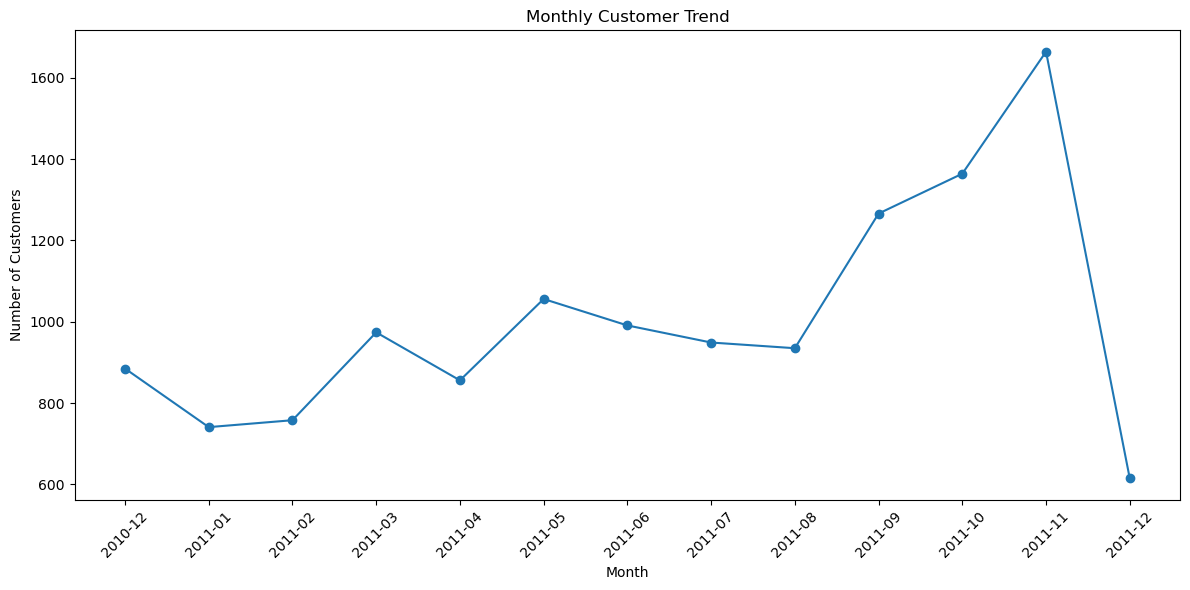

In [35]:
## customer trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["Year_Month"].astype(str),
    monthly_performance["Customers"],
    marker="o"
)

plt.title("Monthly Customer Trend")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
## average order value

monthly_performance["AOV"] = (
    monthly_performance["Revenue"] /
    monthly_performance["Orders"]
)

monthly_performance

,Year_Month,Revenue,Orders,Customers,AOV
0,2010-12,821452.730,1559,885,526.910026
1,2011-01,689811.610,1086,741,635.185645
2,2011-02,522545.560,1100,758,475.041418
3,2011-03,716215.260,1454,974,492.582710
4,2011-04,536968.491,1246,856,430.953845
5,2011-05,769296.610,1681,1056,457.642243
6,2011-06,760547.010,1533,991,496.116771
7,2011-07,718076.121,1475,949,486.831268
8,2011-08,757841.380,1361,935,556.826877
9,2011-09,1056435.192,1837,1266,575.087203


In [37]:
monthly_performance[[
    "Year_Month",
    "Revenue",
    "Orders",
    "Customers",
    "AOV"
]]

,Year_Month,Revenue,Orders,Customers,AOV
0,2010-12,821452.730,1559,885,526.910026
1,2011-01,689811.610,1086,741,635.185645
2,2011-02,522545.560,1100,758,475.041418
3,2011-03,716215.260,1454,974,492.582710
4,2011-04,536968.491,1246,856,430.953845
5,2011-05,769296.610,1681,1056,457.642243
6,2011-06,760547.010,1533,991,496.116771
7,2011-07,718076.121,1475,949,486.831268
8,2011-08,757841.380,1361,935,556.826877
9,2011-09,1056435.192,1837,1266,575.087203


In [38]:
top_products_revenue = (
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_revenue

,Description,Revenue
0,DOTCOM POSTAGE,206248.77
1,REGENCY CAKESTAND 3 TIER,174156.54
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
4,PARTY BUNTING,99445.23
5,JUMBO BAG RED RETROSPOT,94159.81
6,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,POSTAGE,78101.88
8,Manual,77752.82
9,RABBIT NIGHT LIGHT,66870.03


In [39]:
top_products_quantity = (
    sales_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_quantity

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,JUMBO BAG RED RETROSPOT,48371
4,WHITE HANGING HEART T-LIGHT HOLDER,37872
5,POPCORN HOLDER,36749
6,PACK OF 72 RETROSPOT CAKE CASES,36396
7,ASSORTED COLOUR BIRD ORNAMENT,36362
8,RABBIT NIGHT LIGHT,30739
9,MINI PAINT SET VINTAGE,26633


In [40]:
paper_craft = sales_df[
    sales_df["Description"] == "PAPER CRAFT , LITTLE BIRDIE"
]

paper_craft


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Year_Month
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6,2011,12,December,2011-12


In [41]:
print(paper_craft[[
    "InvoiceNo",
    "Quantity",
    "UnitPrice",
    "Revenue",
    "InvoiceDate",
    "CustomerID",
    "Country"
]])

       InvoiceNo  Quantity  UnitPrice   Revenue         InvoiceDate  \
540421    581483     80995       2.08  168469.6 2011-12-09 09:15:00   

        CustomerID         Country  
540421     16446.0  United Kingdom  


In [42]:
non_product = sales_df[
    sales_df["Description"].str.contains(
        "POSTAGE|Manual",
        case=False,
        na=False
    )
]

print("Non-product transaction rows:", len(non_product))

non_product.groupby("Description")["Revenue"].agg(
    ["sum", "count"]
).sort_values("sum", ascending=False)

Non-product transaction rows: 2149


,sum,count
Description,,
DOTCOM POSTAGE,206248.77,706
POSTAGE,78101.88,1126
Manual,77752.82,317


In [43]:
product_df = sales_df[
    ~sales_df["Description"].str.contains(
        "POSTAGE|Manual",
        case=False,
        na=False
    )
].copy()

print("Original sales rows:", len(sales_df))
print("Product analysis rows:", len(product_df))
print("Rows excluded:", len(sales_df) - len(product_df))

Original sales rows: 524878
Product analysis rows: 522729
Rows excluded: 2149


In [44]:
product_df["Description"].str.contains(
    "POSTAGE|Manual",
    case=False,
    na=False
).sum()

np.int64(0)

In [45]:
top_product_revenue = (
    product_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_product_revenue

,Description,Revenue
0,REGENCY CAKESTAND 3 TIER,174156.54
1,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
3,PARTY BUNTING,99445.23
4,JUMBO BAG RED RETROSPOT,94159.81
5,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
6,RABBIT NIGHT LIGHT,66870.03
7,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
8,ASSORTED COLOUR BIRD ORNAMENT,58927.62
9,CHILLI LIGHTS,54096.36


In [46]:
top_product_quantity = (
    product_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_product_quantity

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,JUMBO BAG RED RETROSPOT,48371
4,WHITE HANGING HEART T-LIGHT HOLDER,37872
5,POPCORN HOLDER,36749
6,PACK OF 72 RETROSPOT CAKE CASES,36396
7,ASSORTED COLOUR BIRD ORNAMENT,36362
8,RABBIT NIGHT LIGHT,30739
9,MINI PAINT SET VINTAGE,26633


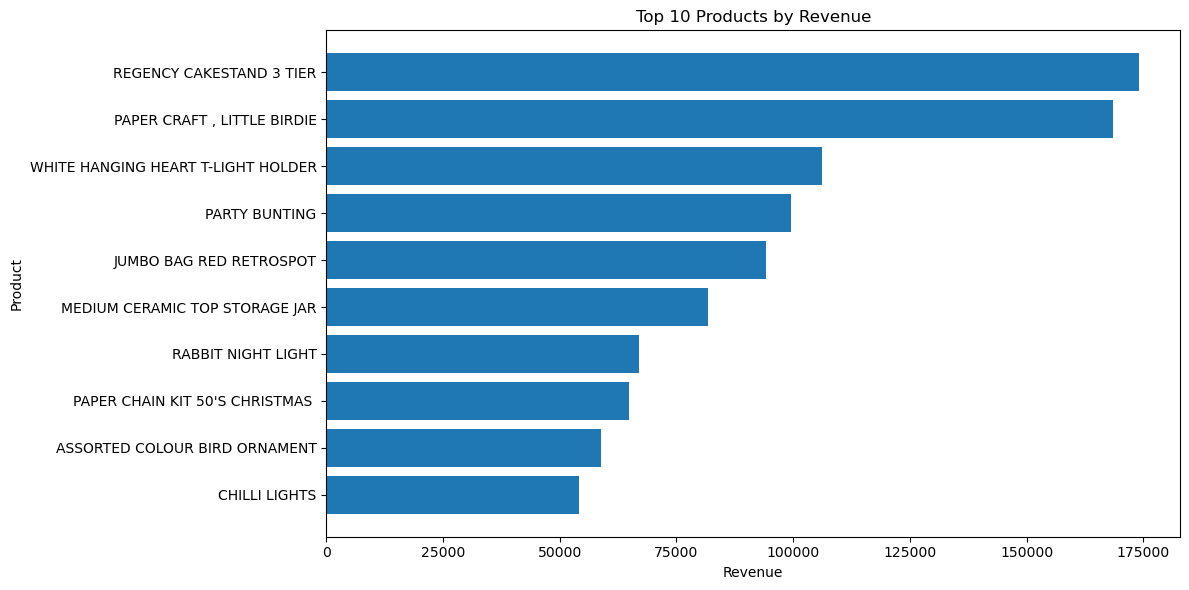

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.barh(
    top_product_revenue["Description"][::-1],
    top_product_revenue["Revenue"][::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

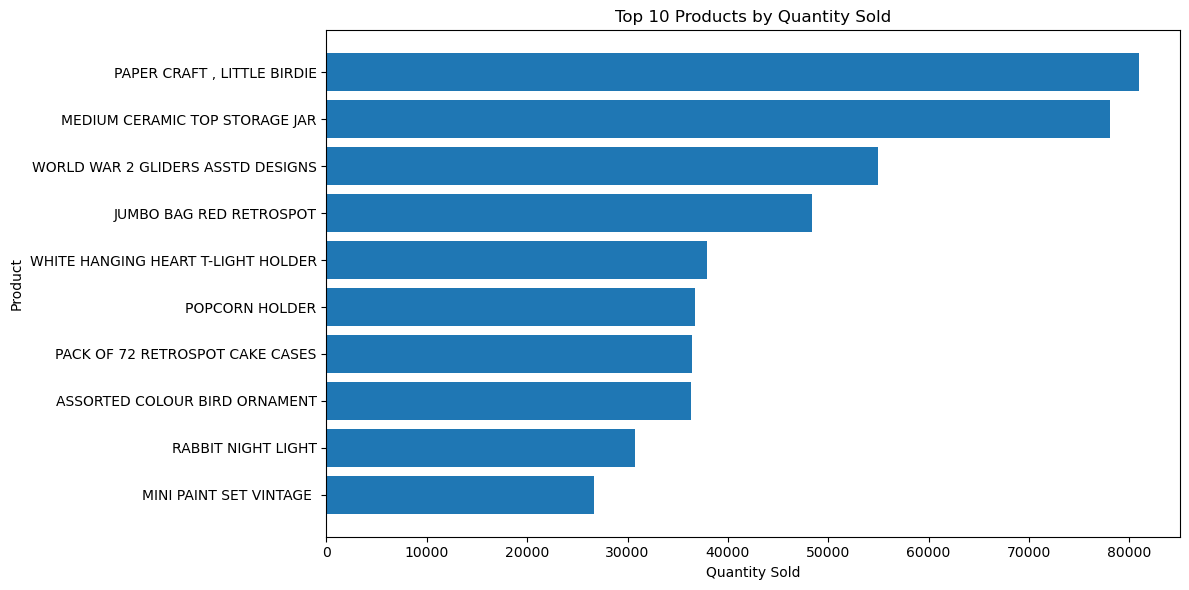

In [48]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_product_quantity["Description"][::-1],
    top_product_quantity["Quantity"][::-1]
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [49]:
product_without_outlier = product_df[
    ~(
        (product_df["InvoiceNo"] == "581483") &
        (product_df["StockCode"] == "23843")
    )
].copy()

In [50]:
quantity_without_outlier = (
    product_without_outlier.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

quantity_without_outlier

,Description,Quantity
0,MEDIUM CERAMIC TOP STORAGE JAR,78033
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
2,JUMBO BAG RED RETROSPOT,48371
3,WHITE HANGING HEART T-LIGHT HOLDER,37872
4,POPCORN HOLDER,36749
5,PACK OF 72 RETROSPOT CAKE CASES,36396
6,ASSORTED COLOUR BIRD ORNAMENT,36362
7,RABBIT NIGHT LIGHT,30739
8,MINI PAINT SET VINTAGE,26633
9,PACK OF 12 LONDON TISSUES,26119


In [51]:
customer_df = sales_df.dropna(subset=["CustomerID"]).copy()

print("Customer analysis rows:", len(customer_df))
print("Unique customers:", customer_df["CustomerID"].nunique())

Customer analysis rows: 392692
Unique customers: 4338


In [52]:
customer_summary = (
    customer_df.groupby("CustomerID")
    .agg(
        Orders=("InvoiceNo", "nunique"),
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

customer_summary.head()

,CustomerID,Orders,Revenue,Quantity
0,12346.0,1,77183.60,74215
1,12347.0,7,4310.00,2458
2,12348.0,4,1797.24,2341
3,12349.0,1,1757.55,631
4,12350.0,1,334.40,197


In [53]:
## one type repeat customers
customer_summary["Customer_Type"] = customer_summary["Orders"].apply(
    lambda x: "One-time" if x == 1 else "Repeat"
)

customer_summary["Customer_Type"].value_counts()

Customer_Type
Repeat      2845
One-time    1493
Name: count, dtype: int64

In [54]:
customer_summary["Customer_Type"].value_counts(normalize=True) * 100

Customer_Type
Repeat      65.583218
One-time    34.416782
Name: proportion, dtype: float64

In [55]:
total_customers = len(customer_summary)

repeat_customers = (
    customer_summary["Customer_Type"] == "Repeat"
).sum()

repeat_rate = (repeat_customers / total_customers) * 100

print("Total customers:", total_customers)
print("Repeat customers:", repeat_customers)
print("Repeat customer rate:", round(repeat_rate, 2), "%")

Total customers: 4338
Repeat customers: 2845
Repeat customer rate: 65.58 %


In [56]:
customer_type_revenue = (
    customer_summary.groupby("Customer_Type")
    .agg(
        Customers=("CustomerID", "count"),
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("Orders", "sum")
    )
    .reset_index()
)

customer_type_revenue

,Customer_Type,Customers,Total_Revenue,Total_Orders
0,One-time,1493,613989.561,1493
1,Repeat,2845,8273219.333,17039


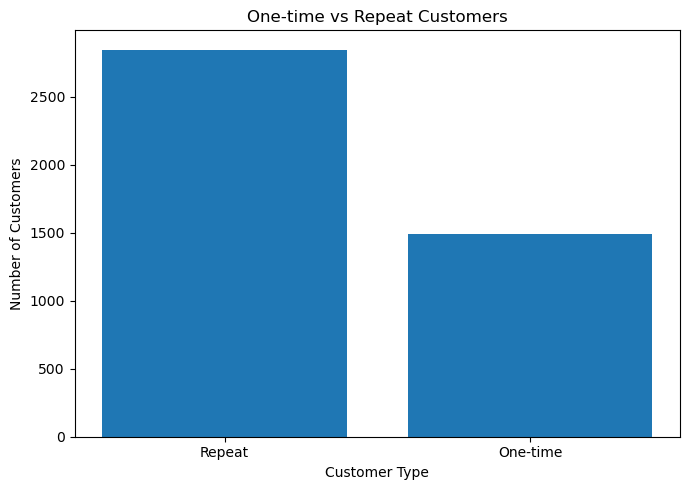

In [57]:
customer_type_counts = customer_summary["Customer_Type"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    customer_type_counts.index,
    customer_type_counts.values
)

plt.title("One-time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [58]:
customer_type_revenue["Revenue_Share_%"] = (
    customer_type_revenue["Total_Revenue"]
    / customer_type_revenue["Total_Revenue"].sum()
    * 100
)

customer_type_revenue

,Customer_Type,Customers,Total_Revenue,Total_Orders,Revenue_Share_%
0,One-time,1493,613989.561,1493,6.908688
1,Repeat,2845,8273219.333,17039,93.091312


In [59]:
customer_type_revenue["Avg_Revenue_Per_Customer"] = (
    customer_type_revenue["Total_Revenue"]
    / customer_type_revenue["Customers"]
)

customer_type_revenue

,Customer_Type,Customers,Total_Revenue,Total_Orders,Revenue_Share_%,Avg_Revenue_Per_Customer
0,One-time,1493,613989.561,1493,6.908688,411.245520
1,Repeat,2845,8273219.333,17039,93.091312,2907.985706


In [60]:
order_frequency = (
    customer_summary["Orders"]
    .value_counts()
    .sort_index()
    .reset_index()
)

order_frequency.columns = ["Number_of_Orders", "Customers"]

order_frequency.head(20)

,Number_of_Orders,Customers
0,1,1493
1,2,835
2,3,508
3,4,388
4,5,242
5,6,172
6,7,143
7,8,98
8,9,68
9,10,54


In [61]:
print("Maximum orders by one customer:",
      customer_summary["Orders"].max())

Maximum orders by one customer: 209


In [62]:
customer_summary["Orders"].describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: Orders, dtype: float64

In [63]:
top_customers = (
    customer_summary
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_customers[[
    "CustomerID",
    "Orders",
    "Revenue"
]]

,CustomerID,Orders,Revenue
1689,14646.0,73,280206.02
4201,18102.0,60,259657.30
3728,17450.0,46,194390.79
3008,16446.0,2,168472.50
1879,14911.0,201,143711.17
55,12415.0,21,124914.53
1333,14156.0,55,117210.08
3771,17511.0,31,91062.38
2702,16029.0,63,80850.84
0,12346.0,1,77183.60


In [64]:
total_customer_revenue = customer_summary["Revenue"].sum()

print("Total identifiable customer revenue:",
      round(total_customer_revenue, 2))

Total identifiable customer revenue: 8887208.89


In [65]:
top_10_revenue = top_customers["Revenue"].sum()

top_10_share = (
    top_10_revenue /
    total_customer_revenue
    * 100
)

print("Top 10 customer revenue:", round(top_10_revenue, 2))
print("Top 10 revenue share:", round(top_10_share, 2), "%")

Top 10 customer revenue: 1537659.21
Top 10 revenue share: 17.3 %


In [66]:
customer_sorted = customer_summary.sort_values(
    "Revenue",
    ascending=False
).reset_index(drop=True)

top_20_count = int(len(customer_sorted) * 0.20)

top_20_revenue = customer_sorted.head(top_20_count)["Revenue"].sum()

top_20_share = (
    top_20_revenue /
    total_customer_revenue
    * 100
)

print("Top 20% customer count:", top_20_count)
print("Top 20% revenue share:", round(top_20_share, 2), "%")

Top 20% customer count: 867
Top 20% revenue share: 74.66 %


In [67]:
customer_summary["Avg_Order_Value"] = (
    customer_summary["Revenue"] /
    customer_summary["Orders"]
)

In [68]:
top_customers_value = (
    customer_summary
    .sort_values("Revenue", ascending=False)
    .head(20)
)

top_customers_value[[
    "CustomerID",
    "Orders",
    "Revenue",
    "Avg_Order_Value"
]]

,CustomerID,Orders,Revenue,Avg_Order_Value
1689,14646.0,73,280206.02,3838.438630
4201,18102.0,60,259657.30,4327.621667
3728,17450.0,46,194390.79,4225.886739
3008,16446.0,2,168472.50,84236.250000
1879,14911.0,201,143711.17,714.980945
55,12415.0,21,124914.53,5948.310952
1333,14156.0,55,117210.08,2131.092364
3771,17511.0,31,91062.38,2937.496129
2702,16029.0,63,80850.84,1283.346667
0,12346.0,1,77183.60,77183.600000


In [69]:
top_aov_customers = (
    customer_summary
    .sort_values("Avg_Order_Value", ascending=False)
    .head(20)
)

top_aov_customers[[
    "CustomerID",
    "Orders",
    "Revenue",
    "Avg_Order_Value"
]]

,CustomerID,Orders,Revenue,Avg_Order_Value
3008,16446.0,2,168472.50,84236.250000
0,12346.0,1,77183.60,77183.600000
2502,15749.0,3,44534.30,14844.766667
2011,15098.0,3,39916.50,13305.500000
10,12357.0,1,6207.67,6207.670000
55,12415.0,21,124914.53,5948.310952
196,12590.0,2,9864.26,4932.130000
278,12688.0,1,4873.81,4873.810000
329,12752.0,1,4366.78,4366.780000
4201,18102.0,60,259657.30,4327.621667


In [70]:
revenue_median = customer_summary["Revenue"].median()
orders_median = customer_summary["Orders"].median()

print("Median customer revenue:", revenue_median)
print("Median customer orders:", orders_median)

Median customer revenue: 668.57
Median customer orders: 2.0


In [71]:
def segment_customer(row):
    if row["Revenue"] >= revenue_median and row["Orders"] >= orders_median:
        return "High Value - Frequent"
    elif row["Revenue"] >= revenue_median and row["Orders"] < orders_median:
        return "High Value - Less Frequent"
    elif row["Revenue"] < revenue_median and row["Orders"] >= orders_median:
        return "Lower Value - Frequent"
    else:
        return "Lower Value - Less Frequent"


customer_summary["Segment"] = customer_summary.apply(
    segment_customer,
    axis=1
)

In [72]:
customer_summary["Segment"].value_counts()

Segment
High Value - Frequent          2022
Lower Value - Less Frequent    1346
Lower Value - Frequent          823
High Value - Less Frequent      147
Name: count, dtype: int64

In [73]:
segment_summary = (
    customer_summary.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("Orders", "sum"),
        Avg_Revenue=("Revenue", "mean"),
        Avg_Orders=("Orders", "mean")
    )
    .reset_index()
)

segment_summary

,Segment,Customers,Total_Revenue,Total_Orders,Avg_Revenue,Avg_Orders
0,High Value - Frequent,2022,7928694.532,14978,3921.213913,7.407517
1,High Value - Less Frequent,147,264641.200,147,1800.280272,1.000000
2,Lower Value - Frequent,823,344524.801,2061,418.620657,2.504253
3,Lower Value - Less Frequent,1346,349348.361,1346,259.545588,1.000000


In [74]:
segment_summary["Revenue_Share_%"] = (
    segment_summary["Total_Revenue"]
    / segment_summary["Total_Revenue"].sum()
    * 100
)

segment_summary

,Segment,Customers,Total_Revenue,Total_Orders,Avg_Revenue,Avg_Orders,Revenue_Share_%
0,High Value - Frequent,2022,7928694.532,14978,3921.213913,7.407517,89.214675
1,High Value - Less Frequent,147,264641.200,147,1800.280272,1.000000,2.977776
2,Lower Value - Frequent,823,344524.801,2061,418.620657,2.504253,3.876637
3,Lower Value - Less Frequent,1346,349348.361,1346,259.545588,1.000000,3.930912


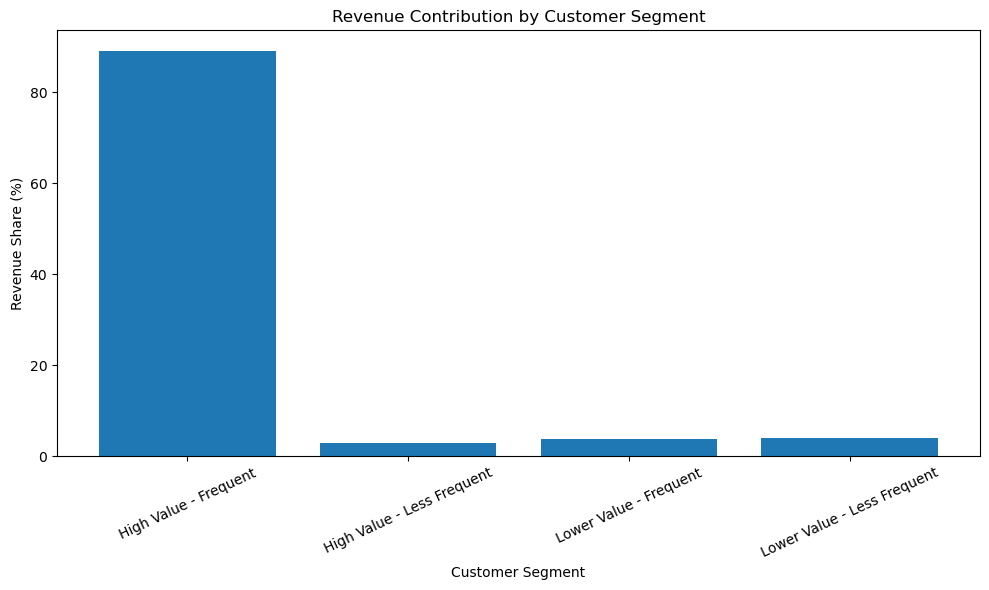

In [75]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Revenue_Share_%"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Share (%)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

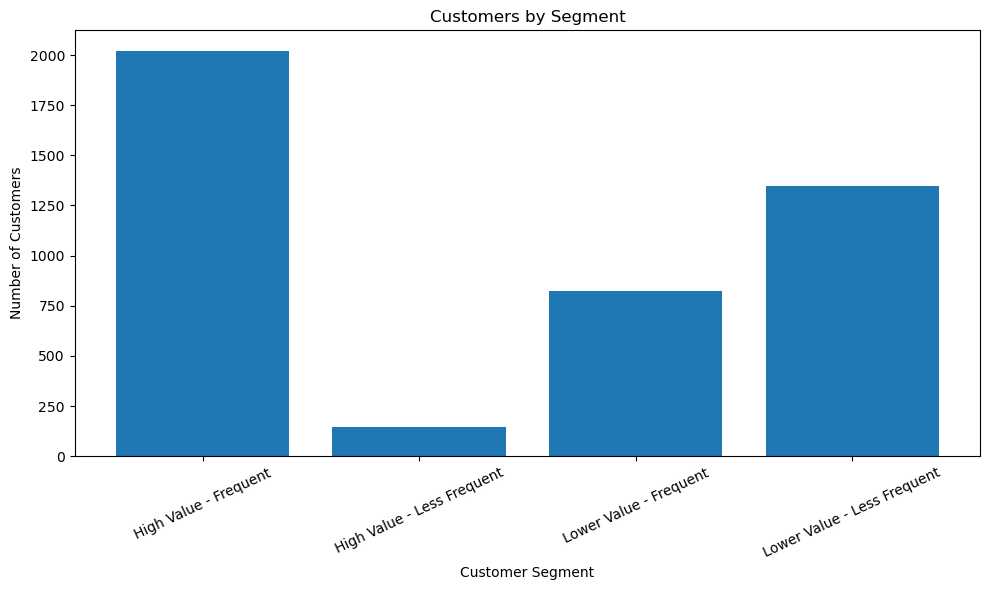

In [76]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Customers"]
)

plt.title("Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [77]:
customer_months = (
    customer_df.groupby("CustomerID")["Year_Month"]
    .nunique()
    .reset_index(name="Active_Months")
)

customer_months.head()

,CustomerID,Active_Months
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [78]:
print("Maximum active months:",
      customer_months["Active_Months"].max())

print("\nActive months distribution:")
print(customer_months["Active_Months"].value_counts().sort_index())

Maximum active months: 13

Active months distribution:
Active_Months
1     1634
2      917
3      530
4      380
5      266
6      171
7       95
8       87
9       74
10      59
11      41
12      40
13      44
Name: count, dtype: int64


In [79]:
customer_summary = customer_summary.merge(
    customer_months,
    on="CustomerID",
    how="left"
)

customer_summary.head()

,CustomerID,Orders,Revenue,Quantity,Customer_Type,Avg_Order_Value,Segment,Active_Months
0,12346.0,1,77183.60,74215,One-time,77183.600000,High Value - Less Frequent,1
1,12347.0,7,4310.00,2458,Repeat,615.714286,High Value - Frequent,7
2,12348.0,4,1797.24,2341,Repeat,449.310000,High Value - Frequent,4
3,12349.0,1,1757.55,631,One-time,1757.550000,High Value - Less Frequent,1
4,12350.0,1,334.40,197,One-time,334.400000,Lower Value - Less Frequent,1


In [80]:
active_month_distribution = (
    customer_months["Active_Months"]
    .value_counts()
    .sort_index()
    .reset_index()
)

active_month_distribution.columns = [
    "Active_Months",
    "Customers"
]

active_month_distribution["Customer_Share_%"] = (
    active_month_distribution["Customers"]
    / active_month_distribution["Customers"].sum()
    * 100
)

active_month_distribution

,Active_Months,Customers,Customer_Share_%
0,1,1634,37.667128
1,2,917,21.138774
2,3,530,12.217612
3,4,380,8.759797
4,5,266,6.131858
5,6,171,3.941909
6,7,95,2.189949
7,8,87,2.005533
8,9,74,1.705855
9,10,59,1.360074


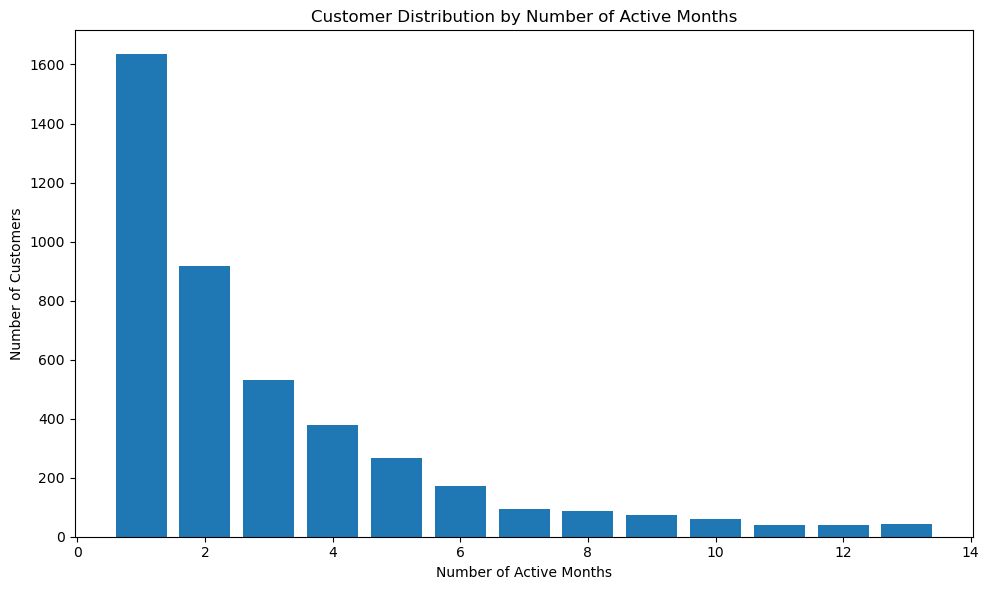

In [81]:
plt.figure(figsize=(10, 6))

plt.bar(
    active_month_distribution["Active_Months"],
    active_month_distribution["Customers"]
)

plt.title("Customer Distribution by Number of Active Months")
plt.xlabel("Number of Active Months")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [82]:
"active_month_revenue" in globals()

False

In [83]:
country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_revenue.head(15)

,Country,Revenue
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


In [84]:
country_customers = (
    customer_df.groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Customers")
)

country_customers.head(15)

,Country,Customers
0,United Kingdom,3920
1,Germany,94
2,France,87
3,Spain,30
4,Belgium,25
5,Switzerland,21
6,Portugal,19
7,Italy,14
8,Finland,12
9,Austria,11


In [85]:
country_orders = (
    sales_df.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Orders")
)

country_orders.head(15)

,Country,Orders
0,United Kingdom,18019
1,Germany,457
2,France,392
3,EIRE,288
4,Belgium,98
5,Netherlands,94
6,Spain,90
7,Portugal,58
8,Australia,57
9,Switzerland,54


In [86]:
country_summary = (
    country_revenue
    .merge(country_orders, on="Country")
    .merge(country_customers, on="Country", how="left")
)

country_summary.head(15)

,Country,Revenue,Orders,Customers
0,United Kingdom,9001744.094,18019,3920.0
1,Netherlands,285446.340,94,9.0
2,EIRE,283140.520,288,3.0
3,Germany,228678.400,457,94.0
4,France,209625.370,392,87.0
5,Australia,138453.810,57,9.0
6,Spain,61558.560,90,30.0
7,Switzerland,57067.600,54,21.0
8,Belgium,41196.340,98,25.0
9,Sweden,38367.830,36,8.0


In [87]:
country_summary["Revenue_per_Order"] = (
    country_summary["Revenue"] /
    country_summary["Orders"]
)

country_summary["Revenue_per_Customer"] = (
    country_summary["Revenue"] /
    country_summary["Customers"]
)

In [88]:
country_summary.sort_values(
    "Revenue_per_Order",
    ascending=False
).head(15)

,Country,Revenue,Orders,Customers,Revenue_per_Order,Revenue_per_Customer
14,Singapore,21279.29,7,1.0,3039.898571,21279.290000
1,Netherlands,285446.34,94,9.0,3036.663191,31716.260000
5,Australia,138453.81,57,9.0,2429.014211,15383.756667
10,Japan,37416.37,19,8.0,1969.282632,4677.046250
30,Lebanon,1693.88,1,1.0,1693.880000,1693.880000
18,Hong Kong,15483.00,11,NaN,1407.545455,NaN
33,Brazil,1143.60,1,1.0,1143.600000,1143.600000
9,Sweden,38367.83,36,8.0,1065.773056,4795.978750
7,Switzerland,57067.60,54,21.0,1056.807407,2717.504762
16,Denmark,18955.34,18,9.0,1053.074444,2106.148889


In [89]:
country_summary.sort_values(
    "Revenue_per_Customer",
    ascending=False
).head(15)

,Country,Revenue,Orders,Customers,Revenue_per_Order,Revenue_per_Customer
2,EIRE,283140.520,288,3.0,983.126806,94380.173333
1,Netherlands,285446.340,94,9.0,3036.663191,31716.260000
14,Singapore,21279.290,7,1.0,3039.898571,21279.290000
5,Australia,138453.810,57,9.0,2429.014211,15383.756667
9,Sweden,38367.830,36,8.0,1065.773056,4795.978750
10,Japan,37416.370,19,8.0,1969.282632,4677.046250
25,Iceland,4310.000,7,1.0,615.714286,4310.000000
11,Norway,36165.440,36,10.0,1004.595556,3616.544000
7,Switzerland,57067.600,54,21.0,1056.807407,2717.504762
21,Israel,8129.410,8,3.0,1016.176250,2709.803333


In [90]:
country_summary["Revenue_Share_%"] = (
    country_summary["Revenue"] /
    country_summary["Revenue"].sum()
    * 100
)

country_summary.sort_values(
    "Revenue",
    ascending=False
).head(15)

,Country,Revenue,Orders,Customers,Revenue_per_Order,Revenue_per_Customer,Revenue_Share_%
0,United Kingdom,9001744.094,18019,3920.0,499.569571,2296.363289,84.586078
1,Netherlands,285446.340,94,9.0,3036.663191,31716.260000,2.682234
2,EIRE,283140.520,288,3.0,983.126806,94380.173333,2.660567
3,Germany,228678.400,457,94.0,500.390372,2432.748936,2.148807
4,France,209625.370,392,87.0,534.758597,2409.487011,1.969772
5,Australia,138453.810,57,9.0,2429.014211,15383.756667,1.301000
6,Spain,61558.560,90,30.0,683.984000,2051.952000,0.578443
7,Switzerland,57067.600,54,21.0,1056.807407,2717.504762,0.536243
8,Belgium,41196.340,98,25.0,420.370816,1647.853600,0.387107
9,Sweden,38367.830,36,8.0,1065.773056,4795.978750,0.360528


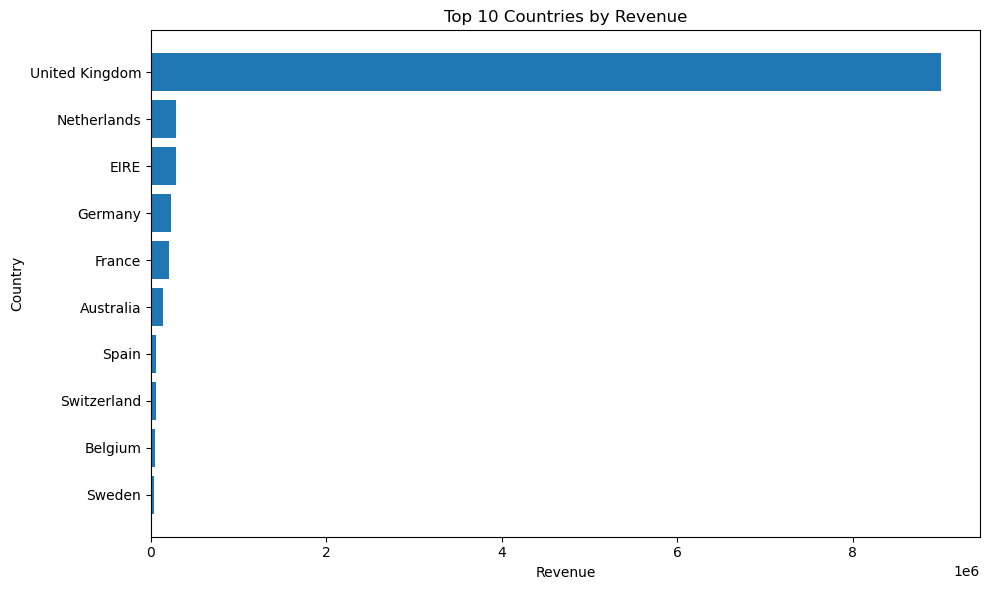

In [91]:
top_countries = country_summary.sort_values(
    "Revenue",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["Country"][::-1],
    top_countries["Revenue"][::-1]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [92]:
monthly_performance["Revenue_Growth_%"] = (
    monthly_performance["Revenue"].pct_change() * 100
)

monthly_performance[
    ["Year_Month", "Revenue", "Revenue_Growth_%"]
]

,Year_Month,Revenue,Revenue_Growth_%
0,2010-12,821452.730,NaN
1,2011-01,689811.610,-16.025404
2,2011-02,522545.560,-24.248077
3,2011-03,716215.260,37.062740
4,2011-04,536968.491,-25.026941
5,2011-05,769296.610,43.266620
6,2011-06,760547.010,-1.137351
7,2011-07,718076.121,-5.584256
8,2011-08,757841.380,5.537750
9,2011-09,1056435.192,39.400568


In [93]:
best_month = monthly_performance.loc[
    monthly_performance["Revenue"].idxmax()
]

worst_month = monthly_performance.loc[
    monthly_performance["Revenue"].idxmin()
]

print("Best month:")
print(best_month)

print("\nWorst month:")
print(worst_month)

Best month:
Year_Month             2011-11
Revenue             1503866.78
Orders                    2769
Customers                 1664
AOV                 543.108263
Revenue_Growth_%     30.627478
Name: 11, dtype: object

Worst month:
Year_Month             2011-02
Revenue              522545.56
Orders                    1100
Customers                  758
AOV                 475.041418
Revenue_Growth_%    -24.248077
Name: 2, dtype: object


In [94]:
growth_data = monthly_performance.dropna(
    subset=["Revenue_Growth_%"]
)

largest_increase = growth_data.loc[
    growth_data["Revenue_Growth_%"].idxmax()
]

largest_decrease = growth_data.loc[
    growth_data["Revenue_Growth_%"].idxmin()
]

print("Largest revenue increase:")
print(largest_increase)

print("\nLargest revenue decrease:")
print(largest_decrease)

Largest revenue increase:
Year_Month             2011-05
Revenue              769296.61
Orders                    1681
Customers                 1056
AOV                 457.642243
Revenue_Growth_%      43.26662
Name: 5, dtype: object

Largest revenue decrease:
Year_Month             2011-12
Revenue              637790.33
Orders                     819
Customers                  615
AOV                 778.742772
Revenue_Growth_%    -57.589972
Name: 12, dtype: object


In [95]:
monthly_performance["Order_Growth_%"] = (
    monthly_performance["Orders"].pct_change() * 100
)

In [96]:
monthly_performance["Customer_Growth_%"] = (
    monthly_performance["Customers"].pct_change() * 100
)

In [97]:
monthly_performance["AOV_Growth_%"] = (
    monthly_performance["AOV"].pct_change() * 100
)

In [98]:
monthly_performance[
    [
        "Year_Month",
        "Revenue",
        "Orders",
        "Customers",
        "AOV",
        "Revenue_Growth_%",
        "Order_Growth_%",
        "Customer_Growth_%",
        "AOV_Growth_%"
    ]
]

,Year_Month,Revenue,Orders,Customers,AOV,Revenue_Growth_%,Order_Growth_%,Customer_Growth_%,AOV_Growth_%
0,2010-12,821452.730,1559,885,526.910026,NaN,NaN,NaN,NaN
1,2011-01,689811.610,1086,741,635.185645,-16.025404,-30.339962,-16.271186,20.549167
2,2011-02,522545.560,1100,758,475.041418,-24.248077,1.289134,2.294197,-25.212192
3,2011-03,716215.260,1454,974,492.582710,37.062740,32.181818,28.496042,3.692582
4,2011-04,536968.491,1246,856,430.953845,-25.026941,-14.305365,-12.114990,-12.511374
5,2011-05,769296.610,1681,1056,457.642243,43.266620,34.911717,23.364486,6.192867
6,2011-06,760547.010,1533,991,496.116771,-1.137351,-8.804283,-6.155303,8.407119
7,2011-07,718076.121,1475,949,486.831268,-5.584256,-3.783431,-4.238143,-1.871636
8,2011-08,757841.380,1361,935,556.826877,5.537750,-7.728814,-1.475237,14.377796
9,2011-09,1056435.192,1837,1266,575.087203,39.400568,34.974284,35.401070,3.279354


In [99]:
full_2011 = monthly_performance[
    (monthly_performance["Year_Month"] >= "2011-01") &
    (monthly_performance["Year_Month"] <= "2011-11")
].copy()

print("Average monthly revenue (Jan-Nov 2011):",
      round(full_2011["Revenue"].mean(), 2))

print("Median monthly revenue (Jan-Nov 2011):",
      round(full_2011["Revenue"].median(), 2))


Average monthly revenue (Jan-Nov 2011): 834806.16
Median monthly revenue (Jan-Nov 2011): 757841.38


In [100]:
active_month_revenue = full_2011.rename(
    columns={"Revenue": "Total_Revenue"}
).copy()

active_month_revenue

,Year_Month,Total_Revenue,Orders,Customers,AOV,Revenue_Growth_%,Order_Growth_%,Customer_Growth_%,AOV_Growth_%
1,2011-01,689811.610,1086,741,635.185645,-16.025404,-30.339962,-16.271186,20.549167
2,2011-02,522545.560,1100,758,475.041418,-24.248077,1.289134,2.294197,-25.212192
3,2011-03,716215.260,1454,974,492.582710,37.062740,32.181818,28.496042,3.692582
4,2011-04,536968.491,1246,856,430.953845,-25.026941,-14.305365,-12.114990,-12.511374
5,2011-05,769296.610,1681,1056,457.642243,43.266620,34.911717,23.364486,6.192867
6,2011-06,760547.010,1533,991,496.116771,-1.137351,-8.804283,-6.155303,8.407119
7,2011-07,718076.121,1475,949,486.831268,-5.584256,-3.783431,-4.238143,-1.871636
8,2011-08,757841.380,1361,935,556.826877,5.537750,-7.728814,-1.475237,14.377796
9,2011-09,1056435.192,1837,1266,575.087203,39.400568,34.974284,35.401070,3.279354
10,2011-10,1151263.730,2040,1364,564.344966,8.976276,11.050626,7.740916,-1.867932


In [101]:
above_average_months = full_2011[
    full_2011["Revenue"] > full_2011["Revenue"].mean()
][[
    "Year_Month",
    "Revenue",
    "Orders",
    "Customers",
    "AOV"
]]

above_average_months

,Year_Month,Revenue,Orders,Customers,AOV
9,2011-09,1056435.192,1837,1266,575.087203
10,2011-10,1151263.730,2040,1364,564.344966
11,2011-11,1503866.780,2769,1664,543.108263


In [102]:
below_average_months = full_2011[
    full_2011["Revenue"] < full_2011["Revenue"].mean()
][[
    "Year_Month",
    "Revenue",
    "Orders",
    "Customers",
    "AOV"
]]

below_average_months

,Year_Month,Revenue,Orders,Customers,AOV
1,2011-01,689811.610,1086,741,635.185645
2,2011-02,522545.560,1100,758,475.041418
3,2011-03,716215.260,1454,974,492.582710
4,2011-04,536968.491,1246,856,430.953845
5,2011-05,769296.610,1681,1056,457.642243
6,2011-06,760547.010,1533,991,496.116771
7,2011-07,718076.121,1475,949,486.831268
8,2011-08,757841.380,1361,935,556.826877


In [103]:
high_period = sales_df[
    sales_df["Year_Month"].astype(str).isin(
        ["2011-09", "2011-10", "2011-11"]
    )
].copy()

In [104]:
high_period_products = (
    high_period.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

high_period_products

,Description,Revenue
0,DOTCOM POSTAGE,70037.93
1,RABBIT NIGHT LIGHT,47435.05
2,PAPER CHAIN KIT 50'S CHRISTMAS,44975.33
3,REGENCY CAKESTAND 3 TIER,36649.35
4,JUMBO BAG RED RETROSPOT,31005.27
5,Manual,30586.28
6,WHITE HANGING HEART T-LIGHT HOLDER,26303.97
7,POSTAGE,24276.16
8,HOT WATER BOTTLE KEEP CALM,24150.60
9,POPCORN HOLDER,22493.68


In [105]:
product_comparison = (
    high_period.groupby("Description")["Revenue"]
    .sum()
    .reset_index(name="Sep_Nov_Revenue")
    .merge(
        product_df[["Description", "Revenue"]],
        on="Description",
        how="left"
    )
)

product_comparison["Sep_Nov_Share_%"] = (
    product_comparison["Sep_Nov_Revenue"]
    / product_comparison["Revenue"]
    * 100
)

product_comparison.sort_values(
    "Sep_Nov_Revenue",
    ascending=False
).head(10)

,Description,Sep_Nov_Revenue,Revenue,Sep_Nov_Share_%
118573,DOTCOM POSTAGE,70037.93,NaN,NaN
328151,RABBIT NIGHT LIGHT,47435.05,85.92,55208.391527
328714,RABBIT NIGHT LIGHT,47435.05,12.48,380088.541667
328701,RABBIT NIGHT LIGHT,47435.05,214.80,22083.356611
328702,RABBIT NIGHT LIGHT,47435.05,12.48,380088.541667
328703,RABBIT NIGHT LIGHT,47435.05,128.88,36805.594351
328704,RABBIT NIGHT LIGHT,47435.05,85.92,55208.391527
328705,RABBIT NIGHT LIGHT,47435.05,198.40,23908.795363
328706,RABBIT NIGHT LIGHT,47435.05,12.48,380088.541667
328707,RABBIT NIGHT LIGHT,47435.05,42.96,110416.783054


In [106]:
# Remove non-product transactions
product_high_period = high_period[
    ~high_period["Description"].str.contains(
        "POSTAGE|Manual",
        case=False,
        na=False
    )
].copy()

In [107]:
product_comparison = (
    high_period.groupby("Description")["Revenue"]
    .sum()
    .reset_index(name="Sep_Nov_Revenue")
)

product_comparison = product_comparison.merge(
    product_df.groupby("Description")["Revenue"]
    .sum()
    .reset_index(name="Total_Revenue"),
    on="Description",
    how="left"
)

product_comparison["Sep_Nov_Share_%"] = (
    product_comparison["Sep_Nov_Revenue"]
    / product_comparison["Total_Revenue"]
    * 100
)

product_comparison = product_comparison.sort_values(
    "Sep_Nov_Revenue",
    ascending=False
)

product_comparison.head(10)

,Description,Sep_Nov_Revenue,Total_Revenue,Sep_Nov_Share_%
855,DOTCOM POSTAGE,70037.93,NaN,NaN
2172,RABBIT NIGHT LIGHT,47435.05,66870.03,70.936188
1913,PAPER CHAIN KIT 50'S CHRISTMAS,44975.33,64875.59,69.325504
2272,REGENCY CAKESTAND 3 TIER,36649.35,174156.54,21.043913
1437,JUMBO BAG RED RETROSPOT,31005.27,94159.81,32.928348
1753,Manual,30586.28,NaN,NaN
3115,WHITE HANGING HEART T-LIGHT HOLDER,26303.97,106236.72,24.759772
2140,POSTAGE,24276.16,NaN,NaN
1358,HOT WATER BOTTLE KEEP CALM,24150.60,28718.80,84.093347
2131,POPCORN HOLDER,22493.68,34288.67,65.600911


In [108]:
full_product_revenue = (
    sales_df[
        ~sales_df["Description"].str.contains(
            "POSTAGE|Manual",
            case=False,
            na=False
            
        )
    ]
    .groupby("Description")["Revenue"]
    .sum()
    .reset_index()
)

In [109]:
# Compare Sep-Nov revenue with total product revenue

product_comparison = (
    high_period_products[
        ["Description", "Revenue"]
    ]
    .rename(columns={"Revenue": "Sep_Nov_Revenue"})
    .merge(
        full_product_revenue[
            ["Description", "Revenue"]
        ].drop_duplicates("Description"),
        on="Description",
        how="left"
    )
    .rename(columns={"Revenue": "Total_Revenue"})
)

product_comparison["Sep_Nov_Share_%"] = (
    product_comparison["Sep_Nov_Revenue"]
    / product_comparison["Total_Revenue"]
    * 100
)

product_comparison.sort_values(
    "Sep_Nov_Revenue",
    ascending=False
).head(10)

,Description,Sep_Nov_Revenue,Total_Revenue,Sep_Nov_Share_%
0,DOTCOM POSTAGE,70037.93,NaN,NaN
1,RABBIT NIGHT LIGHT,47435.05,66870.03,70.936188
2,PAPER CHAIN KIT 50'S CHRISTMAS,44975.33,64875.59,69.325504
3,REGENCY CAKESTAND 3 TIER,36649.35,174156.54,21.043913
4,JUMBO BAG RED RETROSPOT,31005.27,94159.81,32.928348
5,Manual,30586.28,NaN,NaN
6,WHITE HANGING HEART T-LIGHT HOLDER,26303.97,106236.72,24.759772
7,POSTAGE,24276.16,NaN,NaN
8,HOT WATER BOTTLE KEEP CALM,24150.60,28718.80,84.093347
9,POPCORN HOLDER,22493.68,34288.67,65.600911


# Key Insights and Business Recommendations

## Key Insights

### 1. Revenue Performance
- November 2011 was the highest-revenue month with revenue of approximately £1.50 million.
- February 2011 recorded the lowest monthly revenue at approximately £522.55K.
- Revenue increased strongly during September, October, and November, with November showing the strongest overall performance.
- December experienced a sharp decline in revenue, orders, and customers compared with November.

### 2. Customer Retention
- The dataset contains 4,338 identifiable customers.
- 2,845 customers (65.58%) were repeat customers, while 1,493 (34.42%) were one-time customers.
- Repeat customers generated approximately 93.09% of identifiable customer revenue.
- This shows that repeat customers are a major contributor to the business's revenue.

### 3. Customer Value Concentration
- The top 10 customers generated approximately 17.30% of identifiable customer revenue.
- The top 20% of customers contributed approximately 74.66% of identifiable customer revenue.
- This indicates that a relatively small group of high-value customers contributes a large share of revenue.

### 4. Customer Segmentation
- High Value - Frequent customers generated approximately 89.21% of customer revenue.
- Lower Value - Frequent customers accounted for approximately 3.88% of revenue.
- High Value - Less Frequent and Lower Value - Less Frequent customers contributed smaller shares of total revenue.
- The results show that frequent high-value customers are the most important customer segment.

### 5. Product Performance
- PAPER CRAFT, LITTLE BIRDIE had the highest recorded quantity sold at 80,995 units.
- MEDIUM CERAMIC TOP STORAGE JAR was the second-highest by quantity with 78,033 units.
- Several products, including RABBIT NIGHT LIGHT and PAPER CHAIN KIT 50'S CHRISTMAS, showed strong revenue performance during the high-revenue September-November period.

### 6. Geographic Performance
- The United Kingdom generated the majority of revenue, contributing approximately 84.59% of total revenue.
- The Netherlands, EIRE, Germany, and France were among the next highest-revenue countries.
- Some countries had relatively high revenue per customer despite having a small customer base, indicating potential opportunities for targeted international growth.

## Business Recommendations

### 1. Focus on Repeat Customers
Develop loyalty programs, personalized offers, and targeted promotions to retain repeat customers and encourage one-time customers to make additional purchases.

### 2. Protect High-Value Customers
Prioritize high-value frequent customers through exclusive offers, early access to products, personalized recommendations, and loyalty benefits.

### 3. Increase One-Time Customer Conversion
Create follow-up campaigns for one-time customers using discounts, product recommendations, and reminders to encourage a second purchase.

### 4. Prepare for Seasonal Demand
The strong performance from September to November suggests increased demand during this period. The business should prepare inventory, marketing campaigns, and operational capacity before the high-demand season.

### 5. Investigate December Decline
The sharp December decline should be investigated further to understand whether it was caused by incomplete monthly data, seasonal purchasing patterns, operational factors, or other business conditions.

### 6. Maintain Stock of High-Demand Products
Products with consistently high quantities sold should be monitored closely to reduce the risk of stockouts during high-demand periods.

### 7. Explore International Markets
The United Kingdom dominates revenue, but countries such as the Netherlands, Germany, France, Australia, and Japan show potential for further international growth. Targeted marketing could be used to test expansion opportunities.

### 8. Use Customer Data for Targeted Marketing
Customer segments can be used to create different marketing strategies rather than treating all customers equally. High-value customers can receive retention-focused campaigns, while lower-value customers can receive offers designed to increase order frequency and spending.

 # Conclusion
 This analysis provides an overview of sales, products, customers and geographic performance in the Online Retail dataset.

The analysis shows that revenue is strongly concentrated among repeat and high-value customers, while sales increase substantially toward the September–November period. Seasonal products also show strong revenue concentration during this period.

The findings suggest that the business can improve performance by focusing on customer retention, high-value customers, seasonal inventory planning, targeted promotions and international market opportunities.